## Download datasets (CYGNSS and GRDC)

Importing Packages

In [1]:
#pip install earthaccess

Defaulting to user installation because normal site-packages is not writeable
^C
ERROR: Operation cancelled by user
Note: you may need to restart the kernel to use updated packages.


In [1]:
# IMPORT PACKAGES
import earthaccess
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import xarray as xr
import requests
import os
from tempfile import NamedTemporaryFile
import pandas as pd
import tenacity
print('packages have been imported!')

packages have been imported!


## 1) CYGNSS


In [ ]:
# Parameters to change
years = [2024, 2020, 2019, 2018, 2017, 2016]
satellite = 'CYGNSS_L3_UC_BERKELEY_WATERMASK_DAILY_V3.2'

#target_dir = f'/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CYGNSS/Data/sls_test'
target_dir = f'/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CYGNSS/Data/sls_CYGNSS_DAILY_WATERMASK/'
# ------------------------------
# Log in, input year to download
print('> logging into earthaccess...')
earthaccess.login()
print('> logged in!')

In [ ]:
# Tenacity logic for exponential backoff (github fix for earthaccess bug)
always_retry = tenacity.retry(wait=tenacity.wait_random_exponential(multiplier=1, max=60))
tenaciously_download_file = always_retry(earthaccess.__store__._download_file)
earthaccess.__store__._download_file = tenaciously_download_file

# Search for files
for year in years:
    earthaccess.login()
    print(f'> querying PACE data, year: {year}...')
    results = earthaccess.search_data(
        short_name = satellite,
        temporal=(f'{year}-01-01',f'{year+1}-01-01'), #Search all data from a given year
        count=600)
    results_df = pd.json_normalize(results) #Print results as a pandas dataframe
    
    # Create dir if doenst exist
    year_dir = os.path.join(target_dir, str(year))
    os.makedirs(year_dir, exist_ok=True)
    
    # Save csv to dir
    csv_path = os.path.join(year_dir, f"{satellite}_{year}_results.csv")
    results_df.to_csv(csv_path, index=False)
    results_df.head()
    
    # Download files
    print(f'Downloading to: {year_dir}')
    print(f'Total files to download: {len(results)}')
    
    # Download all files at once
    print('> downloading PACE data...')
    earthaccess.download(results, year_dir)
    print("> Download completed!")

> querying PACE data, year: 2024...
Total files to download: 367
> downloading PACE data...


QUEUEING TASKS | :   0%|          | 0/367 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/367 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/367 [00:00<?, ?it/s]

> Download completed!
> querying PACE data, year: 2020...
Total files to download: 367
> downloading PACE data...


...

PROCESSING TASKS | :   0%|          | 0/367 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/367 [00:00<?, ?it/s]

> Download completed!
> querying PACE data, year: 2019...
Total files to download: 366
> downloading PACE data...


QUEUEING TASKS | :   0%|          | 0/366 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/366 [00:00<?, ?it/s]

/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CYGNSS/Data/sls_CYGNSS_DAILY_WATERMASK/2025/cyg.ddmi.2025-01-01.l3.uc-berkeley-watermask-daily.a32.d33.nc


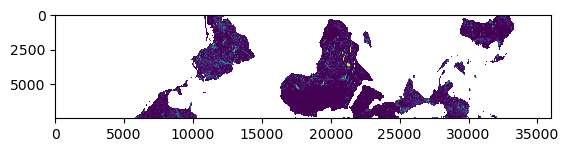

In [27]:
# Test downloaded scenes
import xarray as xr
test = results_df.iloc[0]['meta.native-id']
test_fn = f'{year_dir}/{test}.nc'
print(test_fn)
test_ds = xr.open_dataset(test_fn)
plt.imshow(test_ds['watermask'])

## 2) Inspect outputs of CSMUB V2 loop

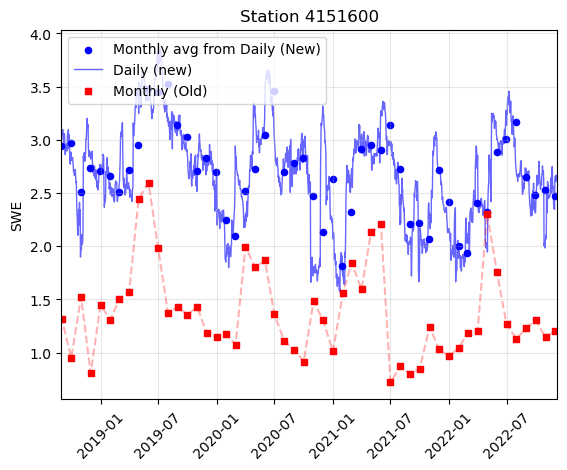

In [2]:
daily_dir =  '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/RESULTS/sls_Daily'
monthly_dir = '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/RESULTS/CSV'
masterlist = '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/GRDC_Stations_UPDATED.csv'
stations_df = pd.read_csv(masterlist)
station_num = stations_df['grdc_no']

n = 481
station_idx=stations_df.iloc[n]['grdc_no']
try: 
    daily_df = pd.read_csv(f'{daily_dir}/{station_idx}_parallel.csv')
except:
    daily_df = pd.read_csv(f'{daily_dir}/{station_idx}_parallel2.csv')
    
monthly_df = pd.read_csv(f'{monthly_dir}/{station_idx}.csv')
# Monthly from daily:
daily_df['Date'] = pd.to_datetime(daily_df['Date'])

# Compute monthly averages from the daily SWE
monthly_avg_from_daily = (
    daily_df
    .set_index('Date')
    .resample('M')['SWE']
    .mean()
    .reset_index()
)
station_dir = '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CYGNSS/Data/sls_GRDC_shp/GRDC_shp'
station_df = pd.read_csv(f'{station_dir}/{station_idx}_Q_Day.Cmd.txt', delimiter=';',encoding='utf-8',skiprows=36)
station_df = station_df[station_df[' Value'] > 0.1]

# Plot
plt.scatter(pd.to_datetime(monthly_avg_from_daily['Date']), monthly_avg_from_daily['SWE'], label = 'Monthly avg from Daily (New)', c ='blue', s = 20
        , zorder = 1)
plt.plot(pd.to_datetime(daily_df['Date']), daily_df['SWE'], label = 'Daily (new)', c = 'blue', alpha = 0.6, lw = 1, zorder = 0)
plt.scatter(pd.to_datetime(monthly_df['Date']), monthly_df['SWE'], label = 'Monthly (Old)', marker = 's', s = 15, c = 'red', zorder = 2)
plt.plot(pd.to_datetime(monthly_df['Date']), monthly_df['SWE'], linestyle = 'dashed', alpha = 0.3, c = 'red', zorder = 2)

plt.xticks(rotation = 45)
plt.legend(loc = 'upper left')
plt.ylabel('SWE')
plt.grid(alpha = 0.3)
plt.title(f'Station {station_idx}')
#plt.ylim(2,daily_df['SWE'].max() + 3)
#plt.ylim(0, 400)
plt.xlim(daily_df['Date'].min(),daily_df['Date'].max())
plt.show()

### Lag Analysis

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def getLag (n):
    
    # ========================================
    # Load data
    # ========================================
    daily_dir =  '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/RESULTS/sls_Daily'
    monthly_dir = '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/RESULTS/CSV'
    masterlist = '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/GRDC_Stations_UPDATED.csv'
    
    stations_df = pd.read_csv(masterlist)
    station_idx = stations_df.iloc[n]['grdc_no']
    
    # Load DAILY SWE
    try:
        daily_df = pd.read_csv(f"{daily_dir}/{station_idx}_parallel.csv")
    except:
        daily_df = pd.read_csv(f"{daily_dir}/{station_idx}_parallel2.csv")
    
    daily_df['Date'] = pd.to_datetime(daily_df['Date'])
    daily_df = daily_df[daily_df['SWE'] > 0]   # remove zeros
    
    
    # Load MONTHLY SWE (correct timing)
    monthly_df = pd.read_csv(f"{monthly_dir}/{station_idx}.csv")
    monthly_df['Date'] = pd.to_datetime(monthly_df['Date'])
    monthly_df = monthly_df[monthly_df['SWE'] > 0]
    # Create a daily timeline covering the daily SWE range
    date_range = pd.date_range(
        start=daily_df['Date'].min(),
        end=daily_df['Date'].max(),
        freq='D'
    )
    
    # Reindex monthly to daily by forward-filling inside each month
    monthly_daily = (
        monthly_df.set_index('Date')
        .resample('D')
        .ffill()
        .reindex(date_range)
        .ffill()
        .reset_index()
    )
    monthly_daily.head()
    monthly_daily = monthly_daily.rename(columns={"index": "Date"})
    monthly_daily.head()
    
    df = pd.merge(
        daily_df[['Date','SWE']], 
        monthly_daily,
        on='Date',
        how='inner'
    )
    df.head() # x is daily, y is monthly
    df.rename(columns={'SWE_x': 'SWE_daily', 'SWE_y': 'SWE_monthly'}, inplace=True)
    
    def normalize(x):
        return (x - x.min()) / (x.max() - x.min())
    
    df['daily_norm'] = normalize(df['SWE_daily'])
    df['monthly_norm'] = normalize(df['SWE_monthly'])
    df.head()
    return(df,station_idx)

In [4]:
import pandas as pd

# Create empty list to hold dicts for each station
lag_records = []

numbers = range(580)
for n in numbers:
    try:
        df = getLag(n)
        
        # Lag analysis
        x = df['daily_norm'].values
        y = df['monthly_norm'].values
        corr = np.correlate(x - x.mean(), y - y.mean(), mode='full')
        lags = np.arange(-len(x)+1, len(x))
        
        valid_mask = (lags >= 0) & (lags <= 20)
        valid_lags = lags[valid_mask]
        valid_corr = corr[valid_mask]
        
        best_lag_days = valid_lags[np.argmax(valid_corr)]
        print(f"{n} Estimated lag: {best_lag_days} days")
        
        # Append as dict
        lag_records.append({"station_index": n, "best_lag_days": best_lag_days})
        
    except Exception as e:
        print(f"Station {n} failed: {e}")
        continue

# Convert to DataFrame
lag_df = pd.DataFrame(lag_records)
lag_df['station_number'] = lag_df['station_index'].map(station_num)
print(lag_df.head())

Station 0 failed: [Errno 2] No such file or directory: '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/RESULTS/sls_Daily/1159100_parallel2.csv'
Station 1 failed: [Errno 2] No such file or directory: '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/RESULTS/sls_Daily/1159103_parallel2.csv'
2 Estimated lag: 12 days
3 Estimated lag: 20 days
4 Estimated lag: 15 days
5 Estimated lag: 12 days
6 Estimated lag: 12 days
7 Estimated lag: 12 days
8 Estimated lag: 11 days
9 Estimated lag: 12 days
10 Estimated lag: 11 days
11 Estimated lag: 13 days
12 Estimated lag: 13 days
13 Estimated lag: 9 days
14 Estimated lag: 9 days
15 Estimated lag: 13 days
16 Estimated lag: 13 days
17 Estimated lag: 15 days
18 Estimated lag: 12 days
19 Estimated lag: 13 days
20 Estimated lag: 14 days
21 Estimated lag: 18 days
22 Estimated lag: 13 days
23 Estimated lag: 15 days
24 Estimated lag: 14 days
25 Estimated lag: 14 days
26 Estimated lag: 14 days
27 Estimated lag: 14 days
28 Estimated lag: 

83 Estimated lag: 7 days


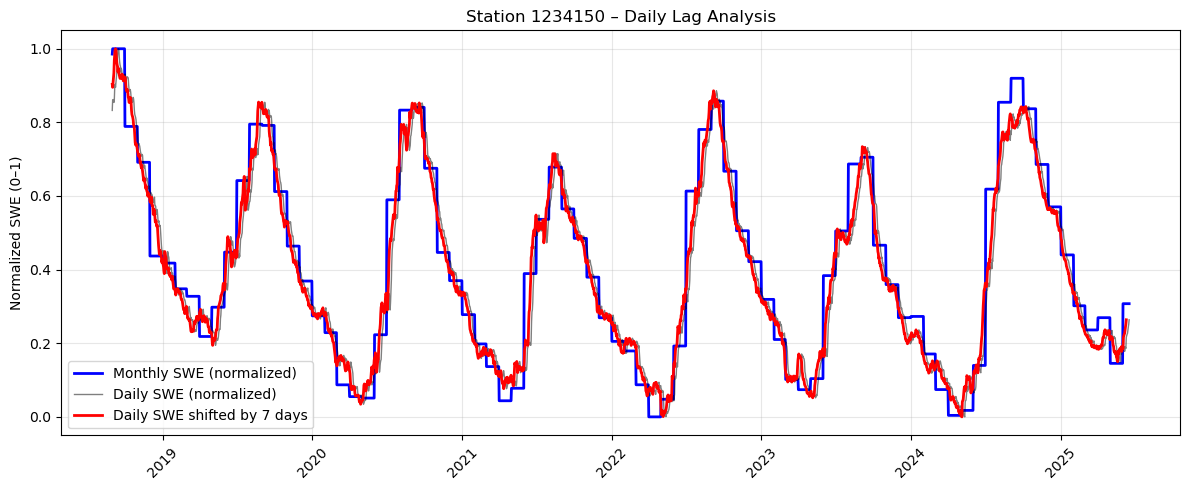

In [38]:
n = 83
df,station_idx = getLag(n)
# Lag analysis --------------
x = df['daily_norm'].values
y = df['monthly_norm'].values
corr = np.correlate(x - x.mean(), y - y.mean(), mode='full')
lags = np.arange(-len(x)+1, len(x))
# Lag calc
valid_mask = (lags >= 0) & (lags <= 20)
valid_lags = lags[valid_mask]
valid_corr = corr[valid_mask]
best_lag_days = valid_lags[np.argmax(valid_corr)]
print(f"{(n)} Estimated lag: {best_lag_days} days")
#lag_list.append(best_lag_days)
# Plot it
df['daily_norm_shifted'] = df['daily_norm'].shift(-best_lag_days)
df_shift = df.dropna(subset=['daily_norm_shifted'])
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['monthly_norm'], label='Monthly SWE (normalized)', lw=2, c = 'b')
plt.plot(df['Date'], df['daily_norm'], label='Daily SWE (normalized)', lw=1, alpha=0.5, c = 'black')
plt.plot(df_shift['Date'], df_shift['daily_norm_shifted'],
         label=f'Daily SWE shifted by {best_lag_days} days', c = 'r', linestyle='-', lw=2)
plt.legend()
plt.grid(alpha=0.3)
plt.title(f"Station {station_idx} – Daily Lag Analysis")
plt.ylabel("Normalized SWE (0–1)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/RESULTS/lag_analysis/lag_plot_station_{station_idx}.pdf", 
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()

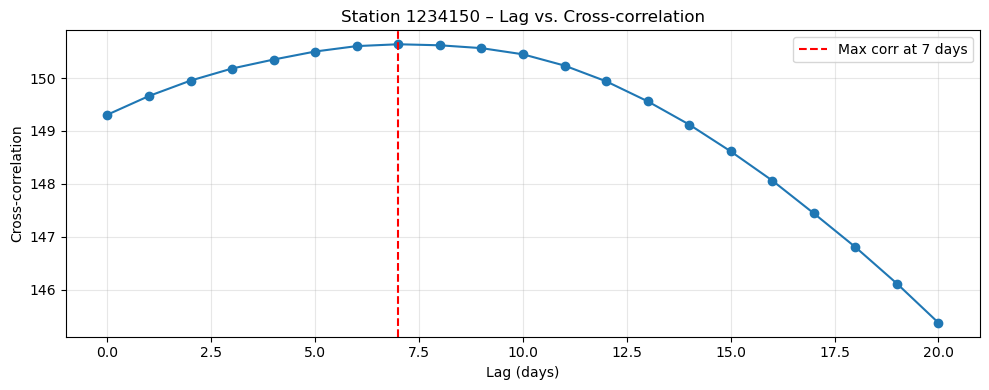

In [39]:
# Cross corr plot
plt.figure(figsize=(10,4))
plt.plot(valid_lags, valid_corr, marker='o')
plt.axvline(best_lag_days, color='r', linestyle='--', label=f'Max corr at {best_lag_days} days')
plt.xlabel('Lag (days)')
plt.ylabel('Cross-correlation')
plt.title(f'Station {station_idx} – Lag vs. Cross-correlation')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/RESULTS/lag_analysis/cross_corr_station_{station_idx}.pdf", 
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()


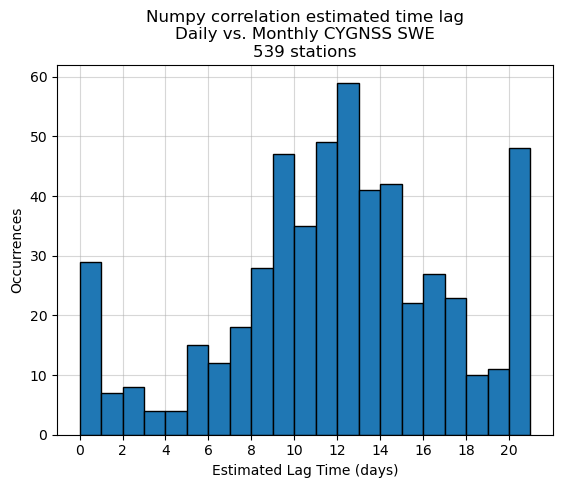

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Define integer bins
bins = range(int(lag_df['best_lag_days'].min()), int(lag_df['best_lag_days'].max()) + 2)

lag_df['best_lag_days'].hist(bins=bins, edgecolor='black', zorder=2)

plt.xlabel('Estimated Lag Time (days)')
plt.ylabel('Occurrences')
plt.grid(alpha=0.5, zorder=0)
plt.title(f'Numpy correlation estimated time lag\nDaily vs. Monthly CYGNSS SWE\n{len(lag_df)} stations')

# Set x-ticks at every integer (or change step to 2, 3, etc.)
plt.xticks(np.arange(lag_df['best_lag_days'].min(), lag_df['best_lag_days'].max() + 1, 2))
plt.savefig(f"/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/RESULTS/lag_analysis/histogram_all_stations.pdf", 
            format='pdf', dpi=300, bbox_inches='tight')

plt.show()


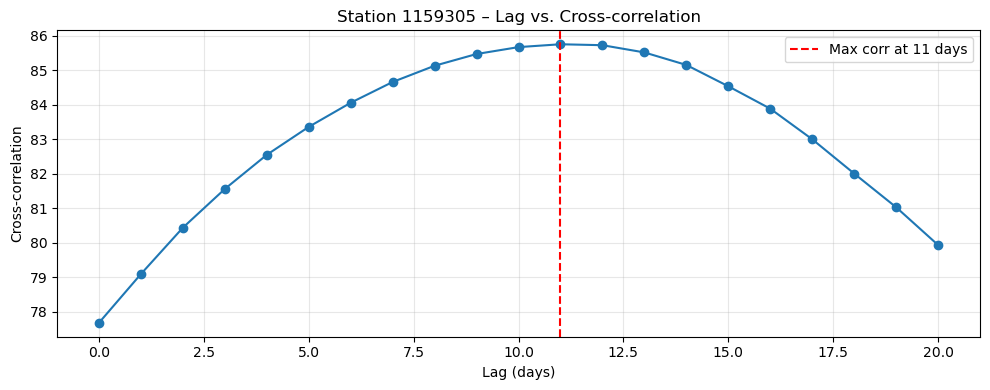

In [23]:
# Cross corr plot
plt.figure(figsize=(10,4))
plt.plot(valid_lags, valid_corr, marker='o')
plt.axvline(best_lag_days, color='r', linestyle='--', label=f'Max corr at {best_lag_days} days')
plt.xlabel('Lag (days)')
plt.ylabel('Cross-correlation')
plt.title(f'Station {station_idx} – Lag vs. Cross-correlation')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/RESULTS/lag_analysis/cross_corr_station_{station_idx}.pdf", 
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()


In [18]:
# Merge for lag
stations_loc = stations_df[['grdc_no', 'lat', 'long']]
lag_df_coords = lag_df.merge(
    stations_loc, 
    left_on='station_number', 
    right_on='grdc_no', 
    how='left'
)

# Optional: drop redundant 'grdc_no' column if desired
lag_df_coords = lag_df_coords.drop(columns=['grdc_no'])

# Reorder columns nicely
lag_df_coords = lag_df_coords[['station_index', 'station_number', 'lat', 'long', 'best_lag_days']]

lag_df_coords

,station_index,station_number,lat,long,best_lag_days
0,2,1159105,-28.075833,16.898333,12
1,3,1159125,-31.437160,20.474169,20
2,4,1159130,-30.474712,20.519176,15
3,5,1159290,-28.774660,20.722429,12
4,6,1159300,-28.457905,21.239235,12
...,...,...,...,...,...
534,551,5606066,-28.824200,114.845500,0
535,552,5606080,-27.856700,114.547000,13
536,553,5606100,-34.071500,115.619000,11
537,554,5606130,-32.772200,116.084300,20


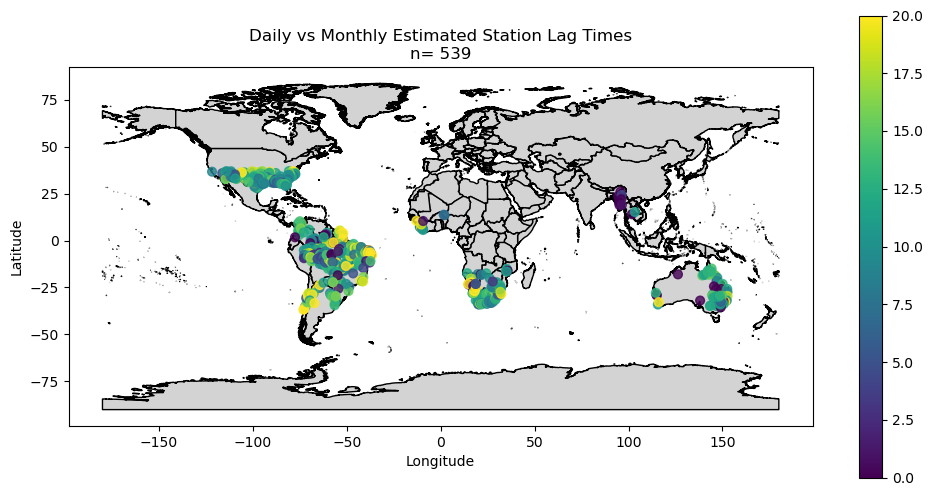

In [21]:
import geopandas as gpd
import matplotlib.pyplot as plt
url = "https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson"
world = gpd.read_file(url)
gdf = gpd.GeoDataFrame(
    lag_df_coords,
    geometry=gpd.points_from_xy(lag_df_coords['long'], lag_df_coords['lat']),
    crs="EPSG:4326"
)
# Plot
fig, ax = plt.subplots(figsize=(12,6))
world.plot(ax=ax, color='lightgray', edgecolor='black')

gdf.plot(
    ax=ax,
    column='best_lag_days',
    cmap='viridis',
    markersize=40,
    legend=True,
    #edgecolor='k',
    alpha=0.8
)

plt.title(f'Daily vs Monthly Estimated Station Lag Times\nn= {len(lag_df)}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.savefig(f"/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/RESULTS/lag_analysis/global_map_all_stations.pdf", 
            format='pdf', dpi=300, bbox_inches='tight')

plt.show()

In [73]:
# Find missing stations
daily_dir = '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/RESULTS/sls_Daily'
masterlist = '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/DATA/GRDC_Stations_UPDATED.csv'
daily_files = os.listdir(daily_dir)
station_ids = set(stations_df['grdc_no'].astype(str))
daily_station_ids = {
    f.split("_")[0]  
    for f in daily_files
    if f.endswith(".csv")
}
daily_done = daily_station_ids.intersection(station_ids)
missing_in_daily = station_ids - daily_done
missing_in_daily

{'1159100',
 '1159103',
 '5204252',
 '5204268',
 '5404270',
 '5404271',
 '5607500',
 '5708110'}

In [74]:
missing_in_daily_int = {int(x) for x in missing_in_daily}
indices = stations_df.index[stations_df['grdc_no'].isin(missing_in_daily_int)].tolist()
indices

[0, 1, 537, 539, 547, 548, 563, 568]